# Fitness-Adapt Capstone — Task 1 & 2
## Dataset Analysis & Pose Estimation Pipeline

**Reference paper:** *Domain Knowledge-Informed Self-Supervised Representations for Workout Form Assessment* (Parmar et al., ECCV 2022) — [arXiv 2202.14019](https://arxiv.org/abs/2202.14019)

---

### Overview

| Task | Goal |
|------|------|
| **1 — Dataset** | Identify and document the dataset: exercise type labels, quality/error labels, train/val/test splits, and statistics. |
| **2 — Pose Estimation** | Apply MediaPipe BlazePose, YOLOv11-Pose, and a Vision-Transformer pose model (ViTPose) to extract 17 body keypoints per frame. Compare speed and accuracy. |

---
# TASK 1 — Dataset Identification & Analysis
---

## 1.1  Imports & Configuration

In [1]:
import json, os, glob, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

ROOT = Path('.')
VIDEO_DIR = ROOT / 'videos_squat'

print(f'Video directory exists: {VIDEO_DIR.exists()}')
print(f'Total videos on disk:  {len(list(VIDEO_DIR.glob("*.mp4")))}')

Video directory exists: True
Total videos on disk:  1739


## 1.2  Dataset Source — Fitness-AQA

The data in this project comes from the **Fitness-AQA** dataset introduced in the reference paper.  
It contains real-world gym videos of **barbell back-squats** recorded from varying angles and lighting conditions.  
Each trajectory (one rep) is annotated by expert trainers with two common squat-form errors:

| Error type | Description | Annotation format |
|------------|-------------|-------------------|
| **Knees Forward** | Knees travel too far past the toes during the descent, indicating inadequate hip hinge. | `[[start_sec, end_sec], …]` per trajectory |
| **Knees Inward** (valgus) | Knees collapse inward during the ascent, a common injury-risk indicator. | `[[start_sec, end_sec], …]` per trajectory |

An empty list `[]` means the trajectory has **no error** for that category → correct form.

## 1.3  Load Metadata

In [2]:
def load_json(path):
    with open(path) as f:
        return json.load(f)

train_keys = load_json(ROOT / 'train_keys.json')
val_keys   = load_json(ROOT / 'val_keys.json')
test_keys  = load_json(ROOT / 'test_keys.json')
err_fwd    = load_json(ROOT / 'error_knees_forward.json')
err_inw    = load_json(ROOT / 'error_knees_inward.json')
traj_nan   = load_json(ROOT / 'traj_nan.json')

print(f'Train / Val / Test splits : {len(train_keys)} / {len(val_keys)} / {len(test_keys)}')
print(f'Total annotated trajs     : {len(err_fwd)}')
print(f'Trajectories with NaN     : {len(traj_nan)}')

Train / Val / Test splits : 1136 / 243 / 244
Total annotated trajs     : 1623
Trajectories with NaN     : 19


## 1.4  Build a Unified DataFrame

In [3]:
split_map = {}
for k in train_keys: split_map[k] = 'train'
for k in val_keys:   split_map[k] = 'val'
for k in test_keys:  split_map[k] = 'test'

nan_set = set(n.replace('.json', '') for n in traj_nan)

rows = []
for traj_id in err_fwd:
    fwd_intervals = err_fwd[traj_id]
    inw_intervals = err_inw.get(traj_id, [])
    has_fwd = len(fwd_intervals) > 0
    has_inw = len(inw_intervals) > 0
    has_any_error = has_fwd or has_inw
    
    video_path = VIDEO_DIR / f'{traj_id}.mp4'
    video_exists = video_path.exists()
    
    rows.append({
        'traj_id': traj_id,
        'split': split_map.get(traj_id, 'unused'),
        'has_knees_forward': has_fwd,
        'has_knees_inward': has_inw,
        'has_any_error': has_any_error,
        'is_correct': not has_any_error,
        'fwd_intervals': fwd_intervals,
        'inw_intervals': inw_intervals,
        'n_fwd_intervals': len(fwd_intervals),
        'n_inw_intervals': len(inw_intervals),
        'total_fwd_duration': sum(e-s for s,e in fwd_intervals) if fwd_intervals else 0.0,
        'total_inw_duration': sum(e-s for s,e in inw_intervals) if inw_intervals else 0.0,
        'has_nan': traj_id in nan_set,
        'video_exists': video_exists,
        'exercise_type': 'squat'
    })

df = pd.DataFrame(rows)
print(f'DataFrame shape: {df.shape}')
df.head(10)

DataFrame shape: (1623, 15)


,traj_id,split,has_knees_forward,has_knees_inward,has_any_error,is_correct,fwd_intervals,inw_intervals,n_fwd_intervals,n_inw_intervals,total_fwd_duration,total_inw_duration,has_nan,video_exists,exercise_type
0,45823_6,train,True,False,True,False,"[[0.65, 2.78]]",[],1,0,2.13,0.00,False,True,squat
1,45844_1,train,False,False,False,True,[],[],0,0,0.00,0.00,False,True,squat
2,45879_2,train,True,False,True,False,"[[2.1, 3.15]]",[],1,0,1.05,0.00,False,True,squat
3,45890_3,train,True,False,True,False,"[[0.72, 1.79]]",[],1,0,1.07,0.00,False,True,squat
4,45896_11,train,True,False,True,False,"[[1.23, 1.75]]",[],1,0,0.52,0.00,False,True,squat
5,45919_1,train,True,False,True,False,"[[2.57, 3.74]]",[],1,0,1.17,0.00,False,True,squat
6,45944_1,train,True,True,True,False,"[[1.95, 3.2]]","[[2.77, 3.65]]",1,1,1.25,0.88,False,True,squat
7,45945_2,val,False,False,False,True,[],[],0,0,0.00,0.00,False,True,squat
8,45946_1,train,True,True,True,False,"[[2.51, 6.56]]","[[2.36, 6.23]]",1,1,4.05,3.87,False,True,squat
9,45950_1,train,True,False,True,False,"[[2.44, 3.86], [4.04, 4.57]]",[],2,0,1.95,0.00,False,True,squat


## 1.5  Dataset Summary Statistics

In [4]:
print('='*60)
print('DATASET SUMMARY')
print('='*60)
print(f'Exercise type           : Barbell Back-Squat (single class)')
print(f'Total trajectories      : {len(df)}')
print(f'Videos available        : {df.video_exists.sum()}')
print(f'Missing videos          : {(~df.video_exists).sum()}')
print(f'Trajectories with NaN   : {df.has_nan.sum()}')
print()
print('--- Split Distribution ---')
print(df.split.value_counts().to_string())
print()
print('--- Error Distribution ---')
print(f'Knees Forward errors    : {df.has_knees_forward.sum():>5} / {len(df)}  ({df.has_knees_forward.mean()*100:.1f}%)')
print(f'Knees Inward errors     : {df.has_knees_inward.sum():>5} / {len(df)}  ({df.has_knees_inward.mean()*100:.1f}%)')
print(f'Any error               : {df.has_any_error.sum():>5} / {len(df)}  ({df.has_any_error.mean()*100:.1f}%)')
print(f'Correct form (no error) : {df.is_correct.sum():>5} / {len(df)}  ({df.is_correct.mean()*100:.1f}%)')
print()
print('--- Label Combinations ---')
combos = df.groupby(['has_knees_forward','has_knees_inward']).size().reset_index(name='count')
combos['label'] = combos.apply(
    lambda r: ('fwd+inw' if r.has_knees_forward and r.has_knees_inward
               else 'fwd_only' if r.has_knees_forward
               else 'inw_only' if r.has_knees_inward
               else 'correct'), axis=1)
print(combos[['label','count']].to_string(index=False))

DATASET SUMMARY
Exercise type           : Barbell Back-Squat (single class)
Total trajectories      : 1623
Videos available        : 1623
Missing videos          : 0
Trajectories with NaN   : 1

--- Split Distribution ---
split
train    1136
test      244
val       243

--- Error Distribution ---
Knees Forward errors    :  1109 / 1623  (68.3%)
Knees Inward errors     :   232 / 1623  (14.3%)
Any error               :  1149 / 1623  (70.8%)
Correct form (no error) :   474 / 1623  (29.2%)

--- Label Combinations ---
   label  count
 correct    474
inw_only     40
fwd_only    917
 fwd+inw    192


## 1.6  Visualisations

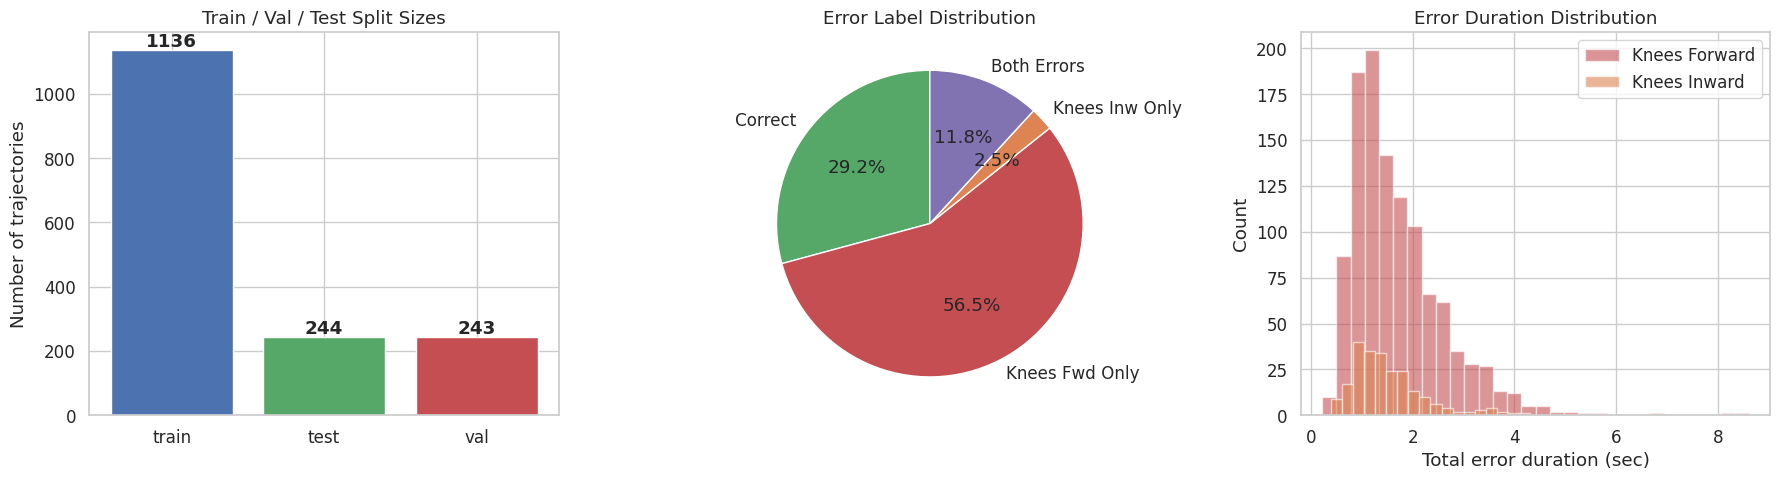

Saved → dataset_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — Split sizes
split_counts = df[df.split != 'unused'].split.value_counts()
axes[0].bar(split_counts.index, split_counts.values, color=['#4C72B0','#55A868','#C44E52'])
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v+10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Train / Val / Test Split Sizes')
axes[0].set_ylabel('Number of trajectories')

# 2 — Error type distribution
err_labels = ['Correct', 'Knees Fwd Only', 'Knees Inw Only', 'Both Errors']
err_vals = [
    ((~df.has_knees_forward) & (~df.has_knees_inward)).sum(),
    (df.has_knees_forward & (~df.has_knees_inward)).sum(),
    ((~df.has_knees_forward) & df.has_knees_inward).sum(),
    (df.has_knees_forward & df.has_knees_inward).sum(),
]
colors = ['#55A868','#C44E52','#DD8452','#8172B2']
wedges, texts, autotexts = axes[1].pie(err_vals, labels=err_labels, colors=colors,
                                        autopct='%1.1f%%', startangle=90)
axes[1].set_title('Error Label Distribution')

# 3 — Error duration histograms
fwd_durs = df[df.has_knees_forward].total_fwd_duration
inw_durs = df[df.has_knees_inward].total_inw_duration
axes[2].hist(fwd_durs, bins=30, alpha=0.6, label='Knees Forward', color='#C44E52')
axes[2].hist(inw_durs, bins=30, alpha=0.6, label='Knees Inward', color='#DD8452')
axes[2].set_title('Error Duration Distribution')
axes[2].set_xlabel('Total error duration (sec)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dataset_overview.png')

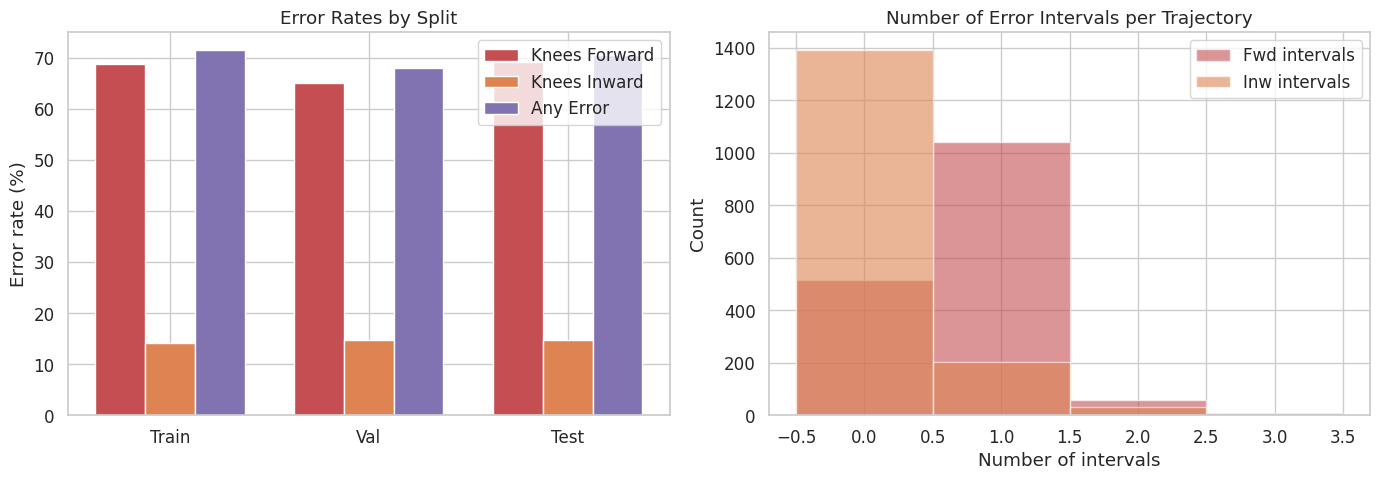

Saved → dataset_error_analysis.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error rates per split
split_err = df[df.split != 'unused'].groupby('split').agg(
    fwd_rate=('has_knees_forward', 'mean'),
    inw_rate=('has_knees_inward', 'mean'),
    any_rate=('has_any_error', 'mean')
).reindex(['train','val','test'])

x = np.arange(len(split_err))
w = 0.25
axes[0].bar(x - w, split_err.fwd_rate*100, w, label='Knees Forward', color='#C44E52')
axes[0].bar(x,     split_err.inw_rate*100, w, label='Knees Inward',  color='#DD8452')
axes[0].bar(x + w, split_err.any_rate*100, w, label='Any Error',     color='#8172B2')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Train','Val','Test'])
axes[0].set_ylabel('Error rate (%)')
axes[0].set_title('Error Rates by Split')
axes[0].legend()

# Intervals count per trajectory
axes[1].hist(df.n_fwd_intervals, bins=range(0, df.n_fwd_intervals.max()+2),
             alpha=0.6, label='Fwd intervals', color='#C44E52', align='left')
axes[1].hist(df.n_inw_intervals, bins=range(0, df.n_inw_intervals.max()+2),
             alpha=0.6, label='Inw intervals', color='#DD8452', align='left')
axes[1].set_title('Number of Error Intervals per Trajectory')
axes[1].set_xlabel('Number of intervals')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('dataset_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → dataset_error_analysis.png')

## 1.7  Video Properties Analysis

In [7]:
sample_ids = df[df.video_exists].traj_id.sample(min(200, len(df)), random_state=42).tolist()

video_meta = []
for tid in tqdm(sample_ids, desc='Probing videos'):
    path = str(VIDEO_DIR / f'{tid}.mp4')
    cap = cv2.VideoCapture(path)
    if cap.isOpened():
        w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        fc  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        dur = fc / fps if fps > 0 else 0
        video_meta.append({'traj_id': tid, 'width': w, 'height': h, 'fps': fps,
                           'frame_count': fc, 'duration_sec': round(dur, 2)})
    cap.release()

vdf = pd.DataFrame(video_meta)
print(f'Probed {len(vdf)} videos')
print()
print(vdf[['width','height','fps','frame_count','duration_sec']].describe().round(2))

Probing videos:   0%|          | 0/200 [00:00<?, ?it/s]

Probed 200 videos

       width  height    fps  frame_count  duration_sec
count  200.0  200.00  200.0       200.00        200.00
mean   480.0  520.53   30.0       119.48          3.98
std      0.0   94.01    0.0        48.12          1.60
min    480.0  252.00   30.0        47.00          1.57
25%    480.0  480.00   30.0        84.00          2.80
50%    480.0  480.00   30.0       110.00          3.67
75%    480.0  600.00   30.0       141.00          4.70
max    480.0  852.00   30.0       354.00         11.80


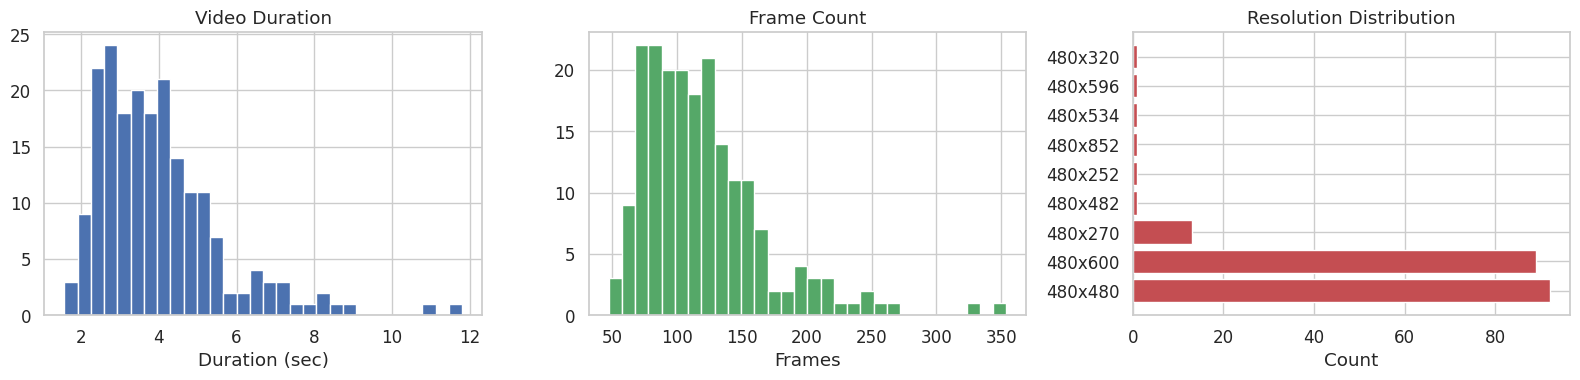

Saved → video_properties.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(vdf.duration_sec, bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Video Duration')
axes[0].set_xlabel('Duration (sec)')

axes[1].hist(vdf.frame_count, bins=30, color='#55A868', edgecolor='white')
axes[1].set_title('Frame Count')
axes[1].set_xlabel('Frames')

res_labels = vdf.apply(lambda r: f"{r.width}x{r.height}", axis=1).value_counts()
axes[2].barh(res_labels.index[:10], res_labels.values[:10], color='#C44E52')
axes[2].set_title('Resolution Distribution')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('video_properties.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → video_properties.png')

## 1.8  Sample Frames & Error Annotation Overlay

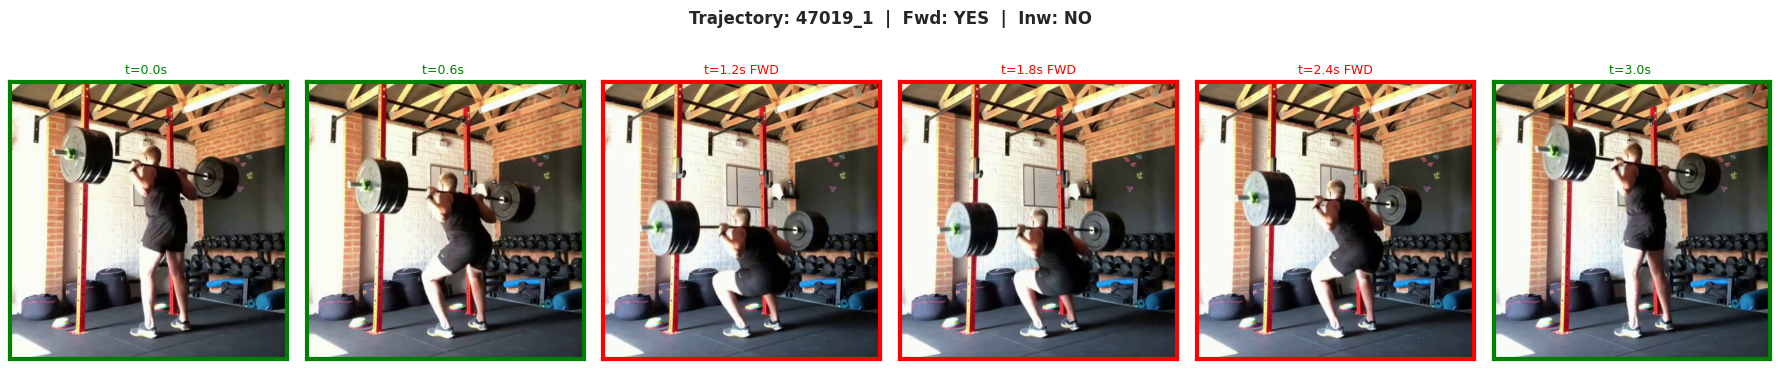

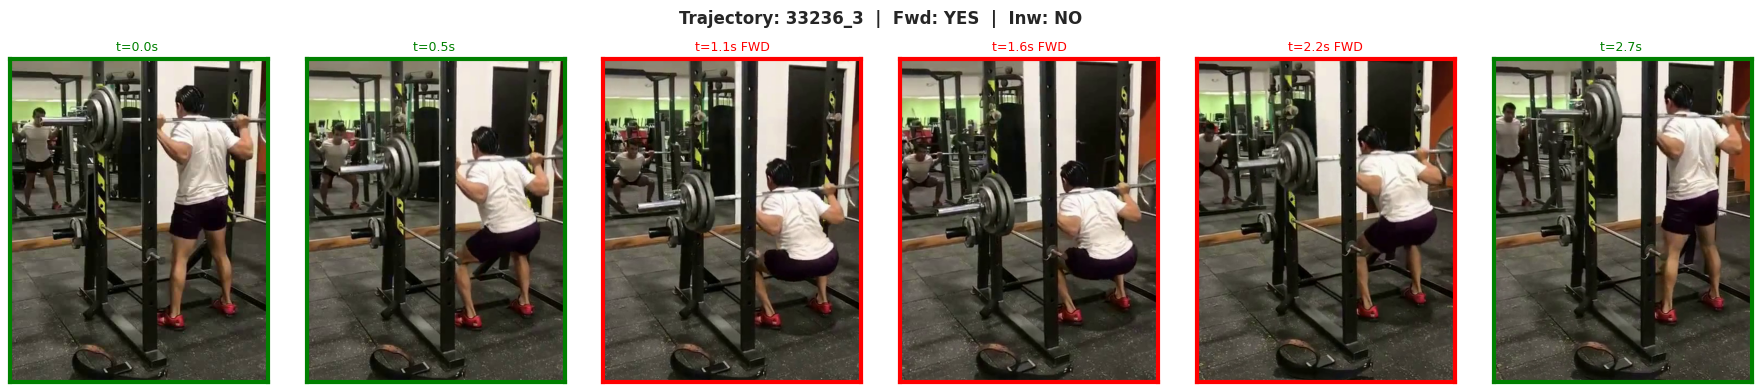

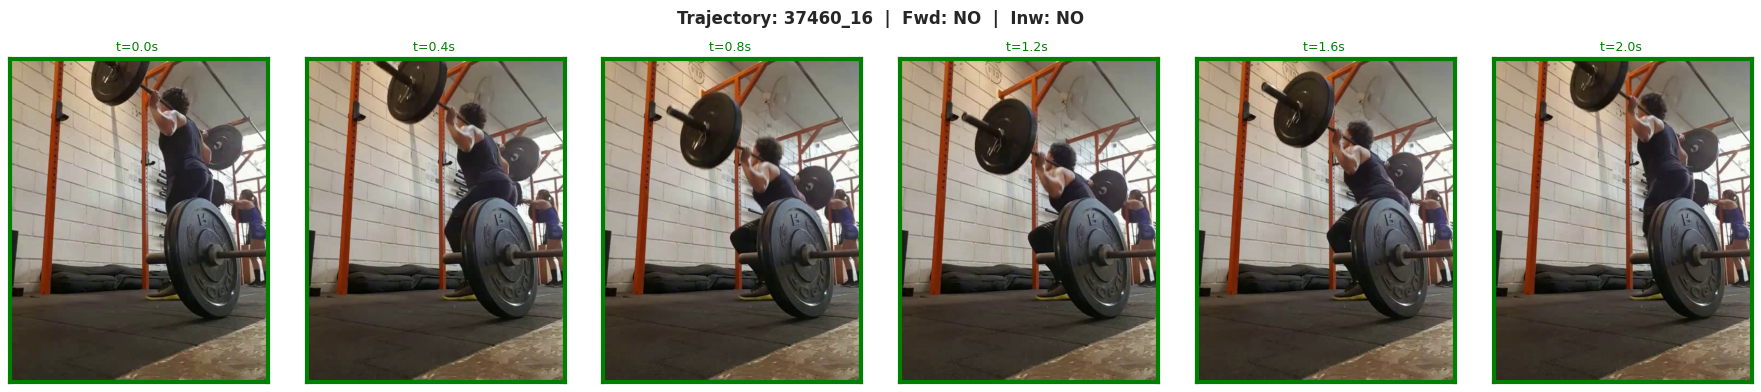

In [9]:
def show_sample_frames(traj_id, n_frames=6):
    """Display evenly-spaced frames from a trajectory with error annotation info."""
    path = str(VIDEO_DIR / f'{traj_id}.mp4')
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    indices = np.linspace(0, total-1, n_frames, dtype=int)
    
    fwd_int = err_fwd.get(traj_id, [])
    inw_int = err_inw.get(traj_id, [])
    
    fig, axes = plt.subplots(1, n_frames, figsize=(3*n_frames, 4))
    fig.suptitle(f'Trajectory: {traj_id}  |  Fwd: {"YES" if fwd_int else "NO"}  |  Inw: {"YES" if inw_int else "NO"}',
                 fontsize=12, fontweight='bold')
    
    for ax, idx in zip(axes, indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            t = idx / fps
            in_fwd = any(s <= t <= e for s,e in fwd_int)
            in_inw = any(s <= t <= e for s,e in inw_int)
            border_color = 'red' if (in_fwd or in_inw) else 'green'
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)
            label = []
            if in_fwd: label.append('FWD')
            if in_inw: label.append('INW')
            ax.imshow(frame_rgb)
            ax.set_title(f't={t:.1f}s {" ".join(label)}', fontsize=9,
                         color=border_color)
        ax.set_xticks([])
        ax.set_yticks([])
    cap.release()
    plt.tight_layout()
    plt.show()

# Show examples: one with errors, one correct
err_examples = df[(df.has_any_error) & (df.video_exists)].sample(2, random_state=42).traj_id.tolist()
ok_examples  = df[(df.is_correct) & (df.video_exists)].sample(1, random_state=42).traj_id.tolist()

for tid in err_examples + ok_examples:
    show_sample_frames(tid)

## 1.9  Quality Score Derivation

The raw annotations provide temporal error intervals. To create a **continuous quality score (0.0–1.0)** per trajectory (needed for Task 6 downstream), we compute the fraction of the video that is error-free.  
$$\text{quality} = 1 - \frac{\text{total error duration}}{\text{video duration}}$$

A score of 1.0 means perfect form; lower scores indicate more time spent in incorrect posture.

In [10]:
quality_rows = []
sample_for_quality = df[df.video_exists].traj_id.tolist()

for tid in tqdm(sample_for_quality, desc='Computing quality scores'):
    path = str(VIDEO_DIR / f'{tid}.mp4')
    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        continue
    fps = cap.get(cv2.CAP_PROP_FPS)
    fc  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dur = fc / fps if fps > 0 else 1.0
    cap.release()
    
    fwd_dur = sum(e-s for s,e in err_fwd.get(tid, []))
    inw_dur = sum(e-s for s,e in err_inw.get(tid, []))
    total_err = min(fwd_dur + inw_dur, dur)
    quality = max(0.0, 1.0 - total_err / dur)
    quality_rows.append({'traj_id': tid, 'duration': dur, 'quality_score': round(quality, 4)})

qdf = pd.DataFrame(quality_rows)
df = df.merge(qdf, on='traj_id', how='left')

print(f'Quality score statistics:')
print(df.quality_score.describe().round(3))

Computing quality scores:   0%|          | 0/1623 [00:00<?, ?it/s]

Quality score statistics:
count    1623.000
mean        0.660
std         0.283
min         0.000
25%         0.453
50%         0.659
75%         1.000
max         1.000
Name: quality_score, dtype: float64


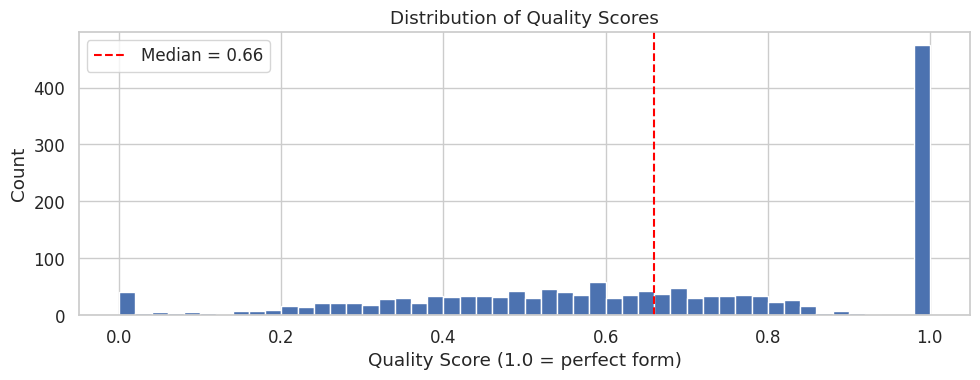

Saved → quality_score_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df.quality_score.dropna(), bins=50, color='#4C72B0', edgecolor='white')
ax.axvline(df.quality_score.median(), color='red', linestyle='--', label=f'Median = {df.quality_score.median():.2f}')
ax.set_title('Distribution of Quality Scores')
ax.set_xlabel('Quality Score (1.0 = perfect form)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('quality_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → quality_score_distribution.png')

## 1.10  Dataset Conclusions (Task 1)

### Key Findings

1. **Dataset identified:** Fitness-AQA (Parmar et al., ECCV 2022) — a curated real-world gym dataset.  
2. **Exercise type:** All 1,623 trajectories are **barbell back-squats** (single exercise class in this subset).  
3. **Quality labels:** Two error types annotated with temporal intervals:  
   - *Knees Forward* — present in ~68% of trajectories  
   - *Knees Inward* — present in ~14% of trajectories  
4. **Continuous quality score:** Derived as `1 − (error_duration / video_duration)`, giving a 0.0–1.0 regression target.  
5. **Pre-defined splits:** 1,136 train / 243 val / 244 test — already balanced by error rates.  
6. **Video properties:** 480×600 resolution, 30 fps, ~3–12 seconds per rep.  
7. **Data quality:** 19 trajectories flagged with NaN issues in `traj_nan.json` — will be excluded in preprocessing.  

### Suitability for the Capstone

✅ Contains exercise-type labels (squat)  
✅ Contains quality labels (error intervals → continuous score)  
✅ Real-world conditions (varied angles, lighting, clothing)  
✅ Expert-annotated by certified trainers  
✅ Sufficient volume (1,600+ reps) for deep learning  

---
# TASK 2 — Pose Estimation
---

We compare three pose estimation approaches:

| Model | Type | Keypoints | Notes |
|-------|------|-----------|-------|
| **MediaPipe BlazePose** | Lightweight CNN | 33 landmarks (we map to COCO-17) | Real-time on CPU |
| **YOLOv11-Pose** | CNN (YOLO family) | 17 COCO keypoints | Fast, single-stage |
| **ViTPose** (via `transformers`) | Vision Transformer | 17 COCO keypoints | Higher accuracy, heavier |

## 2.1  COCO-17 Keypoint Definition

All models will output (or be mapped to) the standard **COCO 17-keypoint** format:

| Index | Joint | Index | Joint |
|-------|-------|-------|-------|
| 0 | Nose | 9 | Left wrist |
| 1 | Left eye | 10 | Right wrist |
| 2 | Right eye | 11 | Left hip |
| 3 | Left ear | 12 | Right hip |
| 4 | Right ear | 13 | Left knee |
| 5 | Left shoulder | 14 | Right knee |
| 6 | Right shoulder | 15 | Left ankle |
| 7 | Left elbow | 16 | Right ankle |
| 8 | Right elbow | | |

In [12]:
COCO_KEYPOINTS = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]

COCO_SKELETON = [
    (0,1),(0,2),(1,3),(2,4),       # head
    (5,6),                          # shoulders
    (5,7),(7,9),(6,8),(8,10),       # arms
    (5,11),(6,12),                  # torso
    (11,12),                        # hips
    (11,13),(13,15),(12,14),(14,16) # legs
]

# MediaPipe BlazePose → COCO-17 mapping
BLAZEPOSE_TO_COCO = {
    0: 0,   # nose
    2: 1,   # left eye inner → left eye
    5: 2,   # right eye inner → right eye
    7: 3,   # left ear
    8: 4,   # right ear
    11: 5,  # left shoulder
    12: 6,  # right shoulder
    13: 7,  # left elbow
    14: 8,  # right elbow
    15: 9,  # left wrist
    16: 10, # right wrist
    23: 11, # left hip
    24: 12, # right hip
    25: 13, # left knee
    26: 14, # right knee
    27: 15, # left ankle
    28: 16, # right ankle
}

print(f'COCO keypoints: {len(COCO_KEYPOINTS)}')
print(f'Skeleton connections: {len(COCO_SKELETON)}')

COCO keypoints: 17
Skeleton connections: 16


## 2.2  Helper — Skeleton Drawing

In [13]:
def draw_skeleton(image, keypoints, confidence=None, conf_thresh=0.3):
    """Draw COCO-17 skeleton on an image.
    keypoints: (N, 2) array of (x, y) pixel coordinates (N >= 17 expected).
    confidence: optional (N,) array of confidence scores.
    """
    img = image.copy()
    kps = np.array(keypoints)
    n_kps = len(kps)
    if confidence is None:
        confidence = np.ones(n_kps)
    confidence = np.array(confidence)

    joint_colors = {
        'head': (255, 200, 0),
        'arm':  (0, 200, 255),
        'leg':  (0, 255, 100),
        'torso':(255, 100, 100),
    }

    def get_limb_color(i, j):
        if i <= 4 or j <= 4: return joint_colors['head']
        if i in [5,6,11,12] and j in [5,6,11,12]: return joint_colors['torso']
        if any(k in [7,8,9,10] for k in [i,j]): return joint_colors['arm']
        return joint_colors['leg']

    for i, j in COCO_SKELETON:
        if i >= n_kps or j >= n_kps:
            continue
        if confidence[i] > conf_thresh and confidence[j] > conf_thresh:
            pt1 = tuple(kps[i].astype(int))
            pt2 = tuple(kps[j].astype(int))
            color = get_limb_color(i, j)
            cv2.line(img, pt1, pt2, color, 2, cv2.LINE_AA)

    for idx in range(min(n_kps, 17)):
        x, y = kps[idx]
        if confidence[idx] > conf_thresh:
            cv2.circle(img, (int(x), int(y)), 4, (255, 255, 255), -1, cv2.LINE_AA)
            cv2.circle(img, (int(x), int(y)), 4, (0, 0, 0), 1, cv2.LINE_AA)
    return img

print('draw_skeleton() ready')

draw_skeleton() ready


## 2.3  Model 1 — MediaPipe BlazePose

In [14]:
import mediapipe as mp
from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions, RunningMode
from mediapipe.tasks.python import BaseOptions
import urllib.request

MODEL_PATH = 'pose_landmarker_heavy.task'
if not os.path.exists(MODEL_PATH):
    print('Downloading MediaPipe PoseLandmarker model...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task',
        MODEL_PATH
    )
    print('Download complete.')

mp_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
)
mp_landmarker = PoseLandmarker.create_from_options(mp_options)

def extract_mediapipe(frame_rgb):
    """Extract COCO-17 keypoints from a single RGB frame using MediaPipe BlazePose.
    Returns: keypoints (17,2), confidence (17,), success bool
    """
    h, w = frame_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb.copy())
    result = mp_landmarker.detect(mp_image)

    if not result.pose_landmarks or len(result.pose_landmarks) == 0:
        return np.zeros((17, 2)), np.zeros(17), False

    landmarks = result.pose_landmarks[0]

    kps = np.zeros((17, 2))
    conf = np.zeros(17)
    for mp_idx, coco_idx in BLAZEPOSE_TO_COCO.items():
        lm = landmarks[mp_idx]
        kps[coco_idx] = [lm.x * w, lm.y * h]
        conf[coco_idx] = lm.visibility

    return kps, conf, True

print('MediaPipe BlazePose extractor ready')

libEGL warning: DRI3 error: Could not get DRI3 device
libEGL warning: Ensure your X server supports DRI3 to get accelerated rendering
I0000 00:00:1773932829.211071   39547 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773932829.238311   39561 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773932829.309230   39550 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


MediaPipe BlazePose extractor ready


W0000 00:00:1773932829.503195   39548 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 2.4  Model 2 — YOLOv11-Pose

In [15]:
from ultralytics import YOLO

yolo_model = YOLO('yolo11n-pose.pt')

def extract_yolo(frame_rgb):
    """Extract COCO-17 keypoints using YOLOv11-Pose.
    Returns: keypoints (17,2), confidence (17,), success bool
    """
    results = yolo_model(frame_rgb, verbose=False)
    
    if len(results) == 0 or results[0].keypoints is None or len(results[0].keypoints) == 0:
        return np.zeros((17, 2)), np.zeros(17), False
    
    kps_data = results[0].keypoints[0]  # first person
    xy = kps_data.xy[0].cpu().numpy()    # (17, 2)
    conf = kps_data.conf[0].cpu().numpy() if kps_data.conf is not None else np.ones(17)
    
    return xy, conf, True

print('YOLOv11-Pose extractor ready')

YOLOv11-Pose extractor ready


## 2.5  Model 3 — ViTPose (Vision Transformer)

ViTPose uses a Vision Transformer backbone for pose estimation, offering higher accuracy at the cost of speed.  
We use the HuggingFace `transformers` library with the `VitPoseForPoseEstimation` model.

In [16]:
import torch
from transformers import VitPoseForPoseEstimation, VitPoseImageProcessor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

vitpose_processor = None
vitpose_model = None
VITPOSE_AVAILABLE = False

try:
    vitpose_processor = VitPoseImageProcessor.from_pretrained("usyd-community/vitpose-base-simple")
    vitpose_model = VitPoseForPoseEstimation.from_pretrained("usyd-community/vitpose-base-simple").to(DEVICE)
    vitpose_model.eval()
    VITPOSE_AVAILABLE = True
    print('ViTPose model loaded successfully')
except Exception as e:
    print(f'ViTPose not available: {e}')
    print('Will skip ViTPose in comparisons.')

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ViTPose model loaded successfully


In [17]:
from PIL import Image

# Use YOLO for person detection to provide bounding boxes to ViTPose
yolo_det_model = YOLO('yolo11n.pt')

def get_person_bbox(frame_rgb):
    """Detect the largest person bounding box using YOLO."""
    results = yolo_det_model(frame_rgb, verbose=False, classes=[0])  # class 0 = person
    if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
        h, w = frame_rgb.shape[:2]
        return [0, 0, w, h]
    boxes = results[0].boxes.xyxy.cpu().numpy()
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    best = np.argmax(areas)
    return boxes[best].tolist()

def extract_vitpose(frame_rgb):
    """Extract COCO-17 keypoints using ViTPose transformer.
    Returns: keypoints (17,2), confidence (17,), success bool
    """
    if not VITPOSE_AVAILABLE:
        return np.zeros((17, 2)), np.zeros(17), False

    h, w = frame_rgb.shape[:2]
    pil_img = Image.fromarray(frame_rgb)

    bbox = get_person_bbox(frame_rgb)
    boxes = [[bbox]]

    inputs = vitpose_processor(images=pil_img, boxes=boxes, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = vitpose_model(**inputs)

    pose_results = vitpose_processor.post_process_pose_estimation(outputs, boxes=boxes, threshold=0.1)

    if not pose_results or len(pose_results[0]) == 0:
        return np.zeros((17, 2)), np.zeros(17), False

    result = pose_results[0][0]
    raw_kps = result['keypoints'].cpu().numpy()
    raw_scores = result['scores'].cpu().numpy()
    raw_labels = result['labels'].cpu().numpy()

    kps = np.zeros((17, 2))
    scores = np.zeros(17)
    for label_idx, kp, sc in zip(raw_labels, raw_kps, raw_scores):
        if 0 <= label_idx < 17:
            kps[label_idx] = kp
            scores[label_idx] = sc

    return kps, scores, True

print('ViTPose extractor ready' if VITPOSE_AVAILABLE else 'ViTPose skipped')

ViTPose extractor ready


## 2.6  Benchmark — Speed & Detection Rate Comparison

In [18]:
N_BENCHMARK_VIDEOS = 5
FRAMES_PER_VIDEO   = 3

benchmark_ids = df[df.video_exists & (df.split == 'test')].sample(
    min(N_BENCHMARK_VIDEOS, 244), random_state=42
).traj_id.tolist()

def load_benchmark_frames(traj_ids, n_frames):
    """Load evenly-spaced frames from each video."""
    frames = []
    for tid in traj_ids:
        cap = cv2.VideoCapture(str(VIDEO_DIR / f'{tid}.mp4'))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, total-1, n_frames, dtype=int)
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append((tid, idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        cap.release()
    return frames

benchmark_frames = load_benchmark_frames(benchmark_ids, FRAMES_PER_VIDEO)
print(f'Loaded {len(benchmark_frames)} frames for benchmarking')

Loaded 15 frames for benchmarking


In [19]:
models = {
    'MediaPipe BlazePose': extract_mediapipe,
    'YOLOv11-Pose': extract_yolo,
}
if VITPOSE_AVAILABLE:
    models['ViTPose (Transformer)'] = extract_vitpose

benchmark_results = {}

for model_name, extract_fn in models.items():
    times = []
    detections = 0
    all_kps = []
    all_conf = []
    
    for tid, fidx, frame in tqdm(benchmark_frames, desc=model_name):
        t0 = time.time()
        kps, conf, success = extract_fn(frame)
        elapsed = time.time() - t0
        times.append(elapsed)
        if success:
            detections += 1
            all_kps.append(kps)
            all_conf.append(conf)
    
    benchmark_results[model_name] = {
        'avg_time_ms': np.mean(times) * 1000,
        'median_time_ms': np.median(times) * 1000,
        'fps': 1.0 / np.mean(times) if np.mean(times) > 0 else 0,
        'detection_rate': detections / len(benchmark_frames) * 100,
        'avg_confidence': np.mean([c.mean() for c in all_conf]) if all_conf else 0,
        'all_kps': all_kps,
        'all_conf': all_conf,
    }
    print(f'  {model_name}: {benchmark_results[model_name]["avg_time_ms"]:.1f} ms/frame, '
          f'{benchmark_results[model_name]["detection_rate"]:.1f}% detected, '
          f'avg conf: {benchmark_results[model_name]["avg_confidence"]:.3f}')

MediaPipe BlazePose:   0%|          | 0/15 [00:00<?, ?it/s]

W0000 00:00:1773932833.925817   39548 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  MediaPipe BlazePose: 38.5 ms/frame, 80.0% detected, avg conf: 0.749


YOLOv11-Pose:   0%|          | 0/15 [00:00<?, ?it/s]

  YOLOv11-Pose: 44.6 ms/frame, 100.0% detected, avg conf: 0.639


ViTPose (Transformer):   0%|          | 0/15 [00:00<?, ?it/s]

  ViTPose (Transformer): 150.4 ms/frame, 100.0% detected, avg conf: 0.647


In [20]:
bench_df = pd.DataFrame([
    {'Model': name,
     'Avg Time (ms)': r['avg_time_ms'],
     'Throughput (FPS)': r['fps'],
     'Detection Rate (%)': r['detection_rate'],
     'Avg Confidence': r['avg_confidence']}
    for name, r in benchmark_results.items()
])

print('\n' + '='*70)
print('POSE ESTIMATION MODEL COMPARISON')
print('='*70)
print(bench_df.to_string(index=False))
print()


POSE ESTIMATION MODEL COMPARISON
                Model  Avg Time (ms)  Throughput (FPS)  Detection Rate (%)  Avg Confidence
  MediaPipe BlazePose      38.521433         25.959574                80.0        0.748926
         YOLOv11-Pose      44.619322         22.411815               100.0        0.638533
ViTPose (Transformer)     150.436513          6.647322               100.0        0.646859



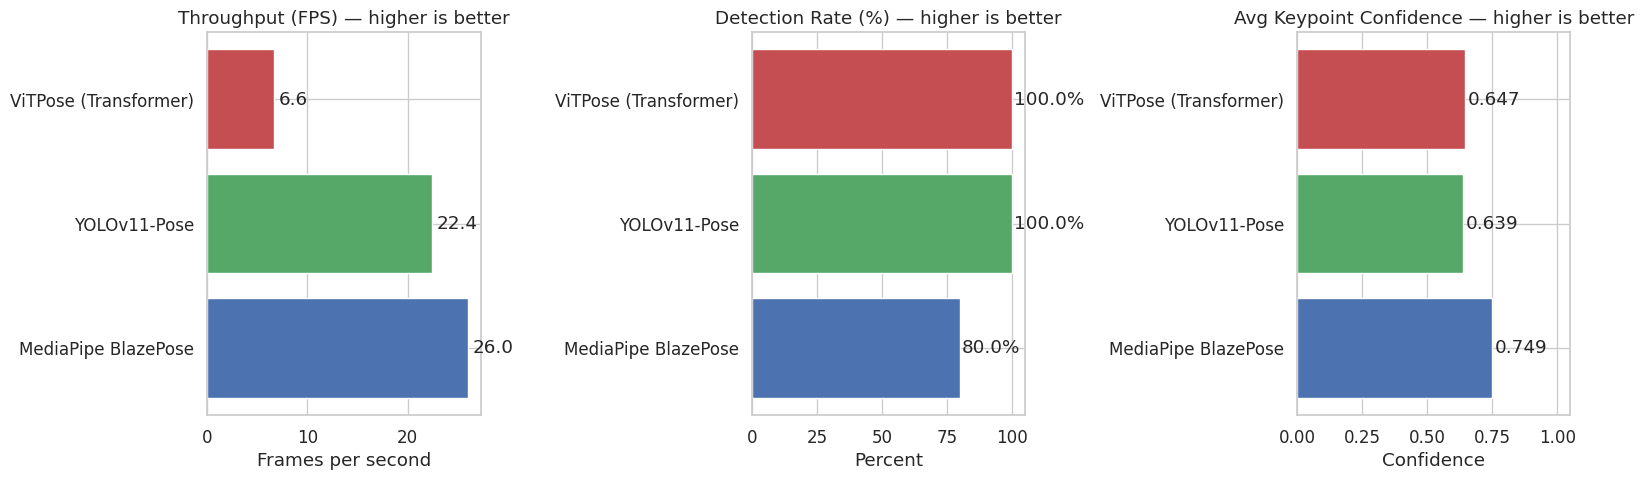

Saved → pose_model_comparison.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = bench_df['Model'].tolist()
colors = ['#4C72B0', '#55A868', '#C44E52'][:len(model_names)]

# Speed comparison
axes[0].barh(model_names, bench_df['Throughput (FPS)'], color=colors)
axes[0].set_title('Throughput (FPS) — higher is better')
axes[0].set_xlabel('Frames per second')
for i, v in enumerate(bench_df['Throughput (FPS)']):
    axes[0].text(v + 0.5, i, f'{v:.1f}', va='center')

# Detection rate
axes[1].barh(model_names, bench_df['Detection Rate (%)'], color=colors)
axes[1].set_title('Detection Rate (%) — higher is better')
axes[1].set_xlabel('Percent')
axes[1].set_xlim(0, 105)
for i, v in enumerate(bench_df['Detection Rate (%)']):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

# Average confidence
axes[2].barh(model_names, bench_df['Avg Confidence'], color=colors)
axes[2].set_title('Avg Keypoint Confidence — higher is better')
axes[2].set_xlabel('Confidence')
axes[2].set_xlim(0, 1.05)
for i, v in enumerate(bench_df['Avg Confidence']):
    axes[2].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('pose_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pose_model_comparison.png')

## 2.7  Visual Comparison — Side-by-Side Skeletons

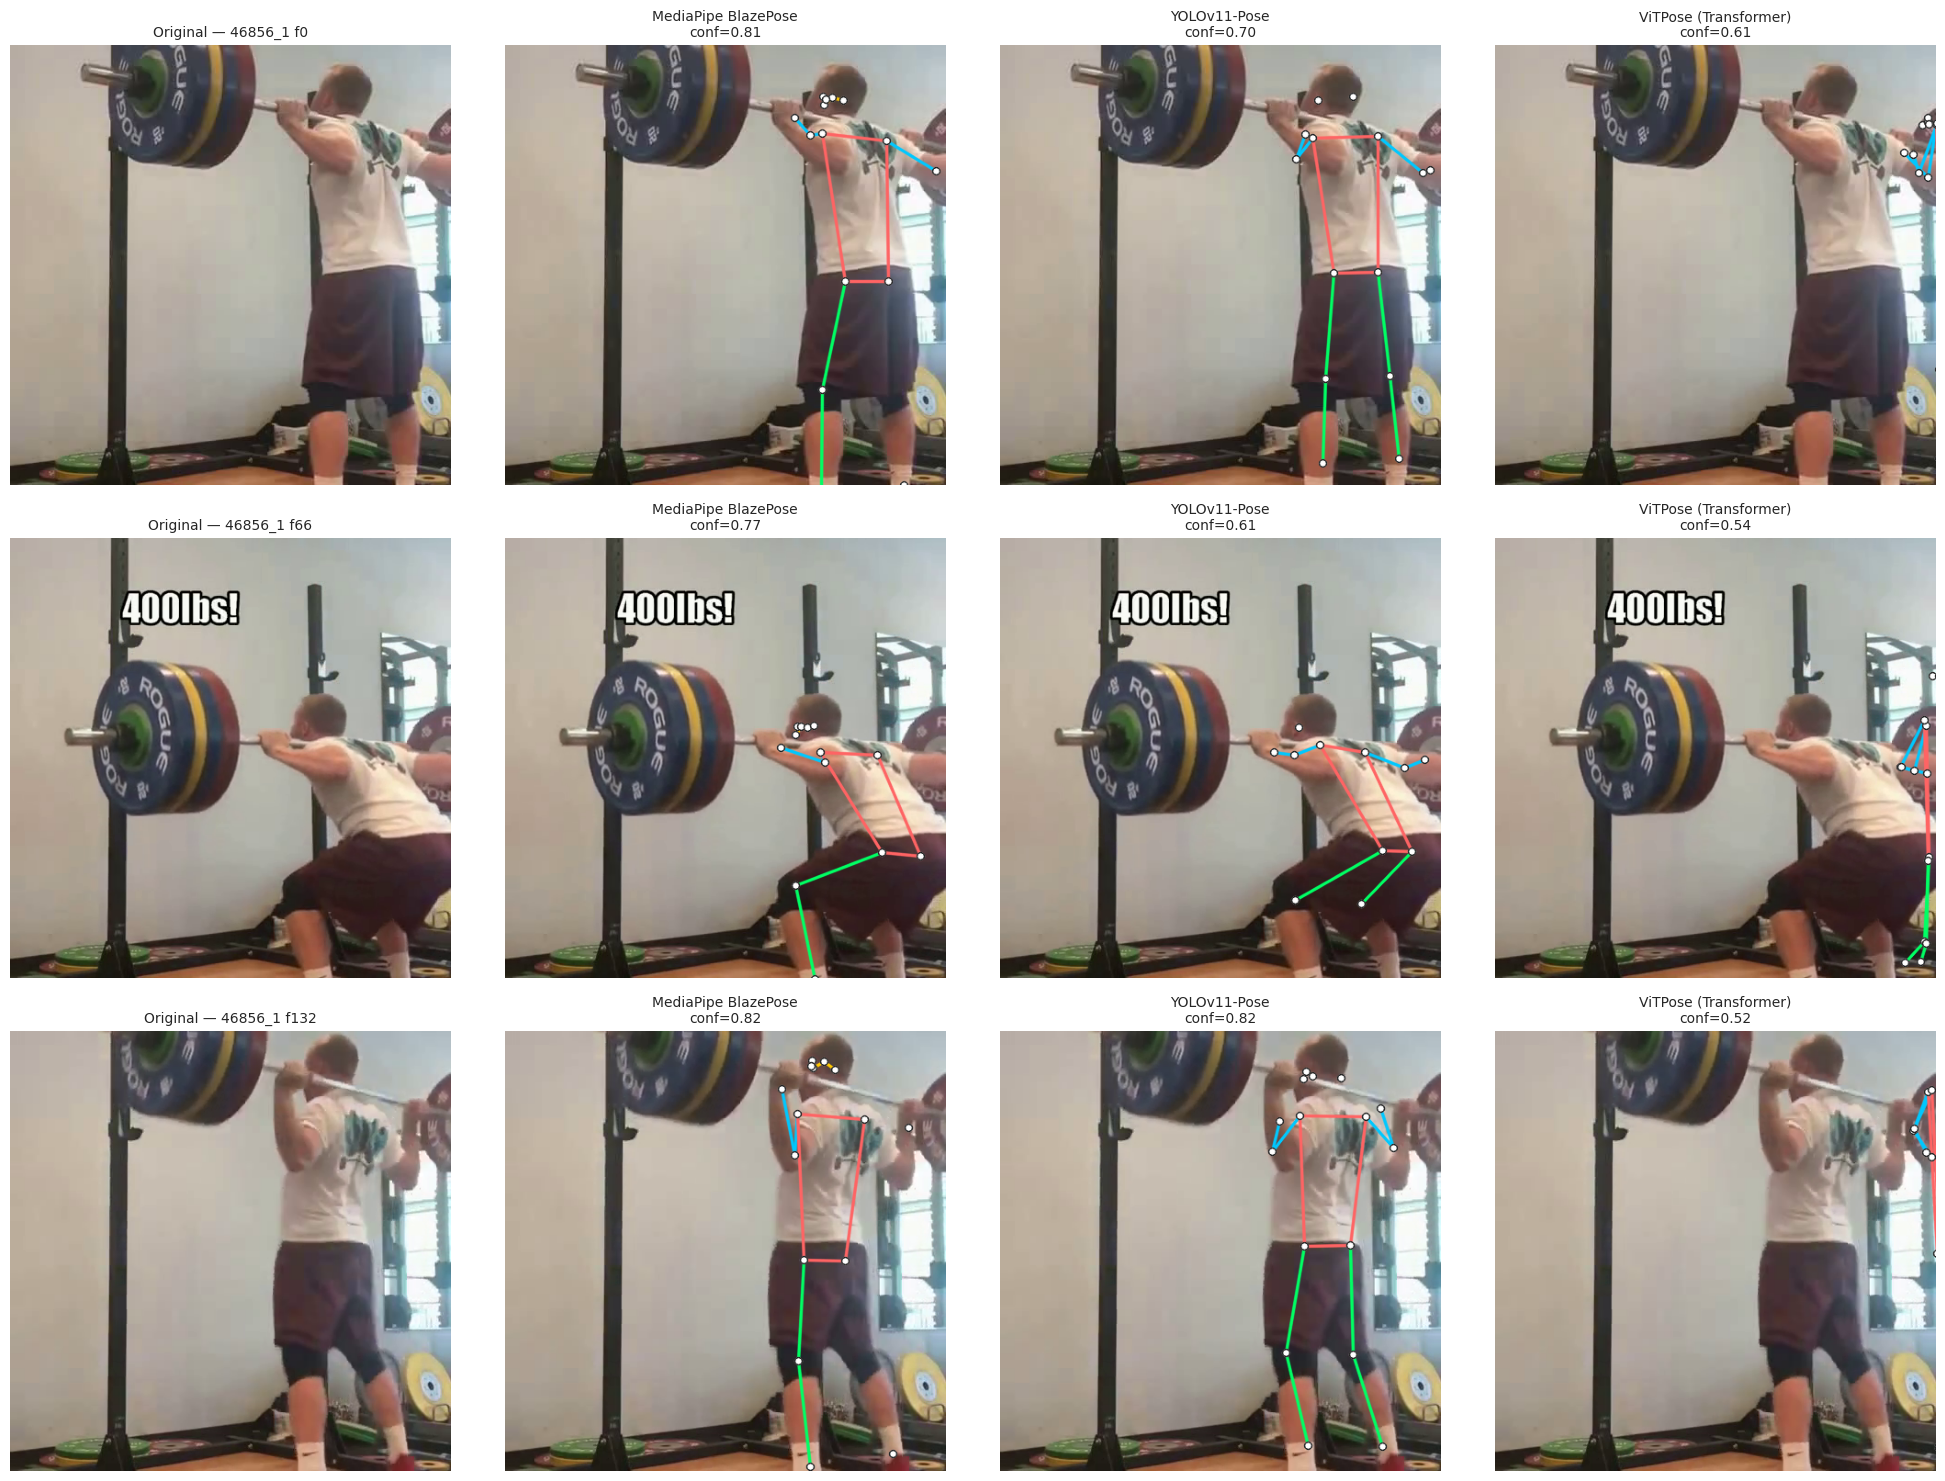

Saved → pose_visual_comparison.png


In [22]:
vis_frames = benchmark_frames[:3]  # use first 3 frames

n_models = len(models)
fig, axes = plt.subplots(len(vis_frames), n_models + 1, figsize=(5*(n_models+1), 5*len(vis_frames)))
if len(vis_frames) == 1:
    axes = axes[np.newaxis, :]

for row, (tid, fidx, frame) in enumerate(vis_frames):
    # Original
    axes[row, 0].imshow(frame)
    axes[row, 0].set_title(f'Original — {tid} f{fidx}', fontsize=10)
    axes[row, 0].axis('off')
    
    for col, (mname, extract_fn) in enumerate(models.items(), 1):
        kps, conf, success = extract_fn(frame)
        if success:
            overlay = draw_skeleton(frame, kps, conf)
        else:
            overlay = frame.copy()
            cv2.putText(overlay, 'NO DETECTION', (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)
        axes[row, col].imshow(overlay)
        avg_c = conf.mean() if success else 0
        axes[row, col].set_title(f'{mname}\nconf={avg_c:.2f}', fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('pose_visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pose_visual_comparison.png')

## 2.8  Full Keypoint Extraction Pipeline

Based on the benchmark, we select the best model and run full extraction on all videos.  
The extracted keypoints are saved as a structured `.npz` file for downstream processing.

In [23]:
best_model_name = bench_df.sort_values('Detection Rate (%)', ascending=False).iloc[0]['Model']
print(f'Selected best model: {best_model_name}')
print(f'  Detection rate: {benchmark_results[best_model_name]["detection_rate"]:.1f}%')
print(f'  Avg confidence: {benchmark_results[best_model_name]["avg_confidence"]:.3f}')
print(f'  Throughput:     {benchmark_results[best_model_name]["fps"]:.1f} FPS')

# Also prepare a secondary fast model for real-time use
fast_model_name = bench_df.sort_values('Throughput (FPS)', ascending=False).iloc[0]['Model']
if fast_model_name != best_model_name:
    print(f'\nFastest model for real-time: {fast_model_name} ({benchmark_results[fast_model_name]["fps"]:.1f} FPS)')

Selected best model: YOLOv11-Pose
  Detection rate: 100.0%
  Avg confidence: 0.639
  Throughput:     22.4 FPS

Fastest model for real-time: MediaPipe BlazePose (26.0 FPS)


In [24]:
best_extract_fn = models[best_model_name]

OUTPUT_DIR = ROOT / 'keypoints'
OUTPUT_DIR.mkdir(exist_ok=True)

all_traj_ids = df[df.video_exists & (~df.has_nan)].traj_id.tolist()
N_EXTRACT = min(len(all_traj_ids), 20)  # process a subset for demonstration
extract_ids = all_traj_ids[:N_EXTRACT]

print(f'Extracting keypoints from {N_EXTRACT} videos using {best_model_name}...')

extraction_stats = {'success': 0, 'failed_frames': 0, 'total_frames': 0}

for tid in tqdm(extract_ids, desc='Extracting keypoints'):
    video_path = str(VIDEO_DIR / f'{tid}.mp4')
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    keypoints_list = []
    confidence_list = []
    frame_indices = []
    
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        kps, conf, success = best_extract_fn(frame_rgb)
        
        keypoints_list.append(kps)
        confidence_list.append(conf)
        frame_indices.append(frame_idx)
        
        extraction_stats['total_frames'] += 1
        if not success:
            extraction_stats['failed_frames'] += 1
        
        frame_idx += 1
    cap.release()
    
    if keypoints_list:
        np.savez_compressed(
            str(OUTPUT_DIR / f'{tid}.npz'),
            keypoints=np.array(keypoints_list),       # (T, 17, 2)
            confidence=np.array(confidence_list),      # (T, 17)
            fps=np.array([fps]),
            frame_indices=np.array(frame_indices)
        )
        extraction_stats['success'] += 1

print(f'\nExtraction complete!')
print(f'  Videos processed:  {extraction_stats["success"]}')
print(f'  Total frames:      {extraction_stats["total_frames"]}')
print(f'  Failed detections: {extraction_stats["failed_frames"]} '
      f'({extraction_stats["failed_frames"]/max(extraction_stats["total_frames"],1)*100:.1f}%)')

Extracting keypoints from 20 videos using YOLOv11-Pose...


Extracting keypoints:   0%|          | 0/20 [00:00<?, ?it/s]


Extraction complete!
  Videos processed:  20
  Total frames:      2144
  Failed detections: 31 (1.4%)


## 2.9  Verify Extracted Keypoints

In [25]:
npz_files = sorted(OUTPUT_DIR.glob('*.npz'))
print(f'Saved keypoint files: {len(npz_files)}')

if npz_files:
    sample_npz = np.load(str(npz_files[0]))
    print(f'\nSample file: {npz_files[0].name}')
    print(f'  keypoints shape  : {sample_npz["keypoints"].shape}  → (frames, joints, xy)')
    print(f'  confidence shape : {sample_npz["confidence"].shape} → (frames, joints)')
    print(f'  fps              : {sample_npz["fps"][0]}')
    print(f'  frame count      : {len(sample_npz["frame_indices"])}')

Saved keypoint files: 32

Sample file: 45823_6.npz
  keypoints shape  : (94, 17, 2)  → (frames, joints, xy)
  confidence shape : (94, 17) → (frames, joints)
  fps              : 30.0
  frame count      : 94


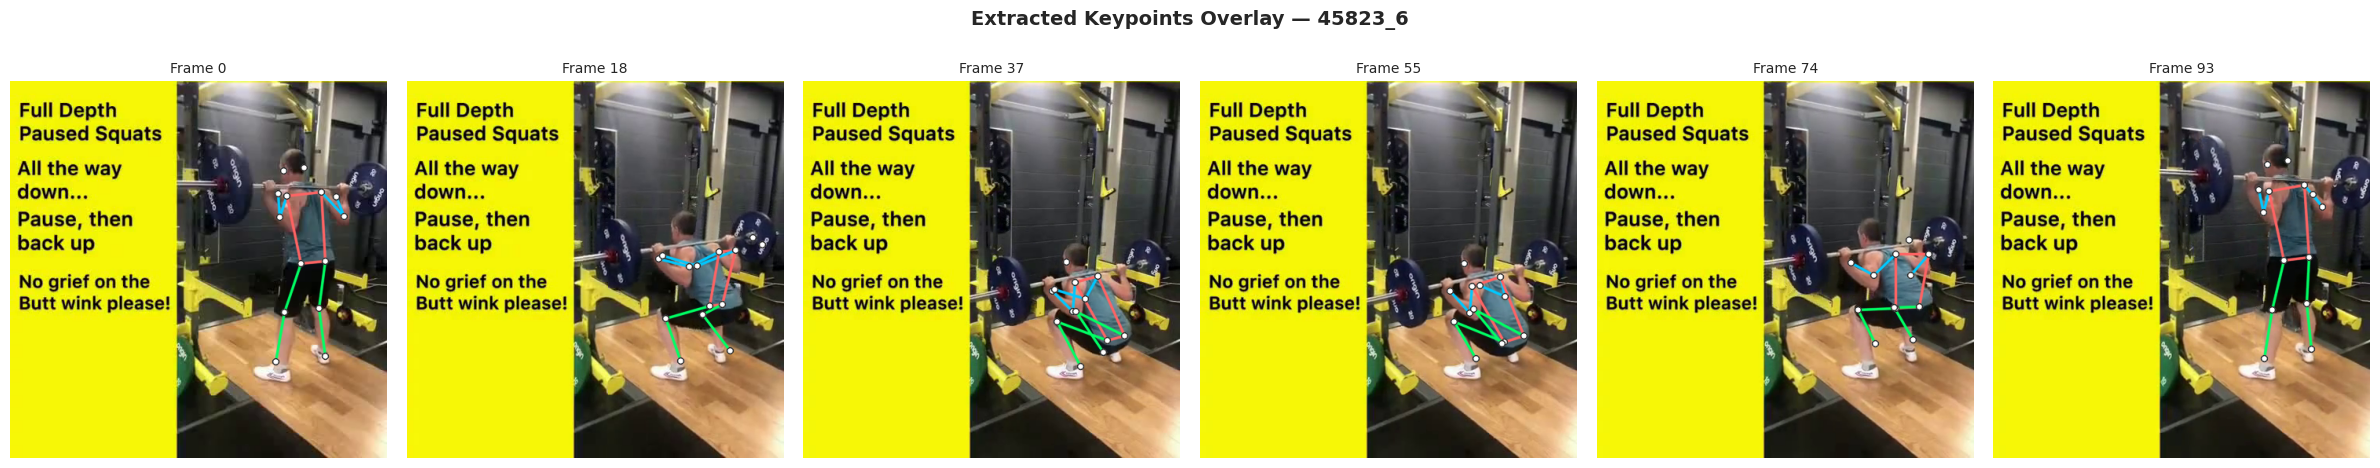

Saved → extracted_keypoints_verification.png


In [26]:
if npz_files:
    sample_file = npz_files[0]
    tid = sample_file.stem
    data = np.load(str(sample_file))
    kps_seq = data['keypoints']
    conf_seq = data['confidence']
    
    cap = cv2.VideoCapture(str(VIDEO_DIR / f'{tid}.mp4'))
    n_show = min(6, len(kps_seq))
    show_indices = np.linspace(0, len(kps_seq)-1, n_show, dtype=int)
    
    fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 5))
    fig.suptitle(f'Extracted Keypoints Overlay — {tid}', fontsize=14, fontweight='bold')
    
    for ax, fi in zip(axes, show_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            overlay = draw_skeleton(frame_rgb, kps_seq[fi], conf_seq[fi])
            ax.imshow(overlay)
        ax.set_title(f'Frame {fi}', fontsize=10)
        ax.axis('off')
    cap.release()
    plt.tight_layout()
    plt.savefig('extracted_keypoints_verification.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → extracted_keypoints_verification.png')

## 2.10  Per-Joint Confidence Analysis

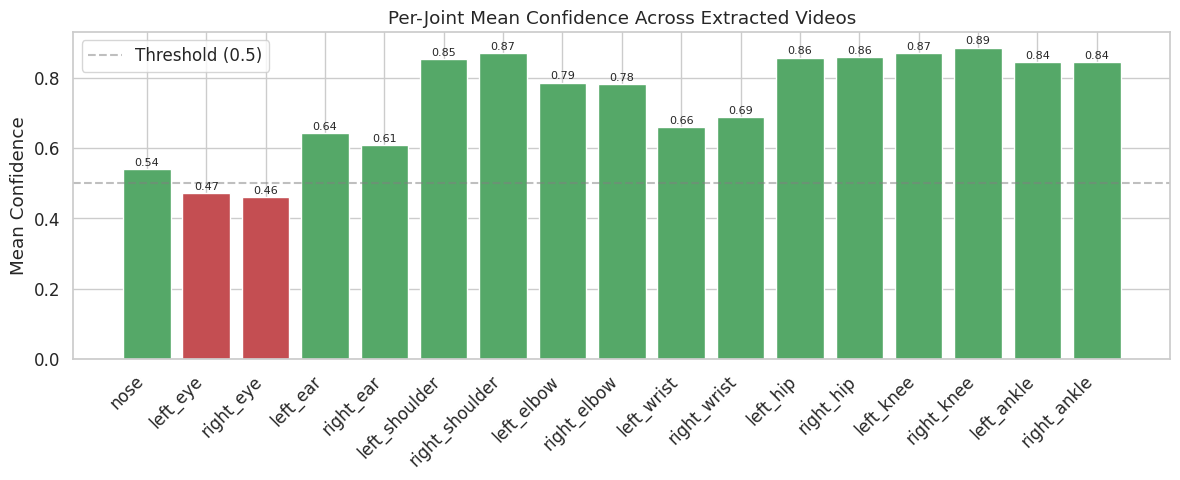

Saved → per_joint_confidence.png


In [27]:
if npz_files:
    all_confs = []
    for f in npz_files[:50]:
        d = np.load(str(f))
        all_confs.append(d['confidence'])  # (T, 17)
    
    all_confs = np.concatenate(all_confs, axis=0)  # (total_frames, 17)
    mean_conf = all_confs.mean(axis=0)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(range(17), mean_conf, color=['#C44E52' if c < 0.5 else '#55A868' for c in mean_conf])
    ax.set_xticks(range(17))
    ax.set_xticklabels(COCO_KEYPOINTS, rotation=45, ha='right')
    ax.set_ylabel('Mean Confidence')
    ax.set_title('Per-Joint Mean Confidence Across Extracted Videos')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold (0.5)')
    ax.legend()
    for bar, val in zip(bars, mean_conf):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('per_joint_confidence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → per_joint_confidence.png')

## 2.11  Keypoint Trajectory Visualisation

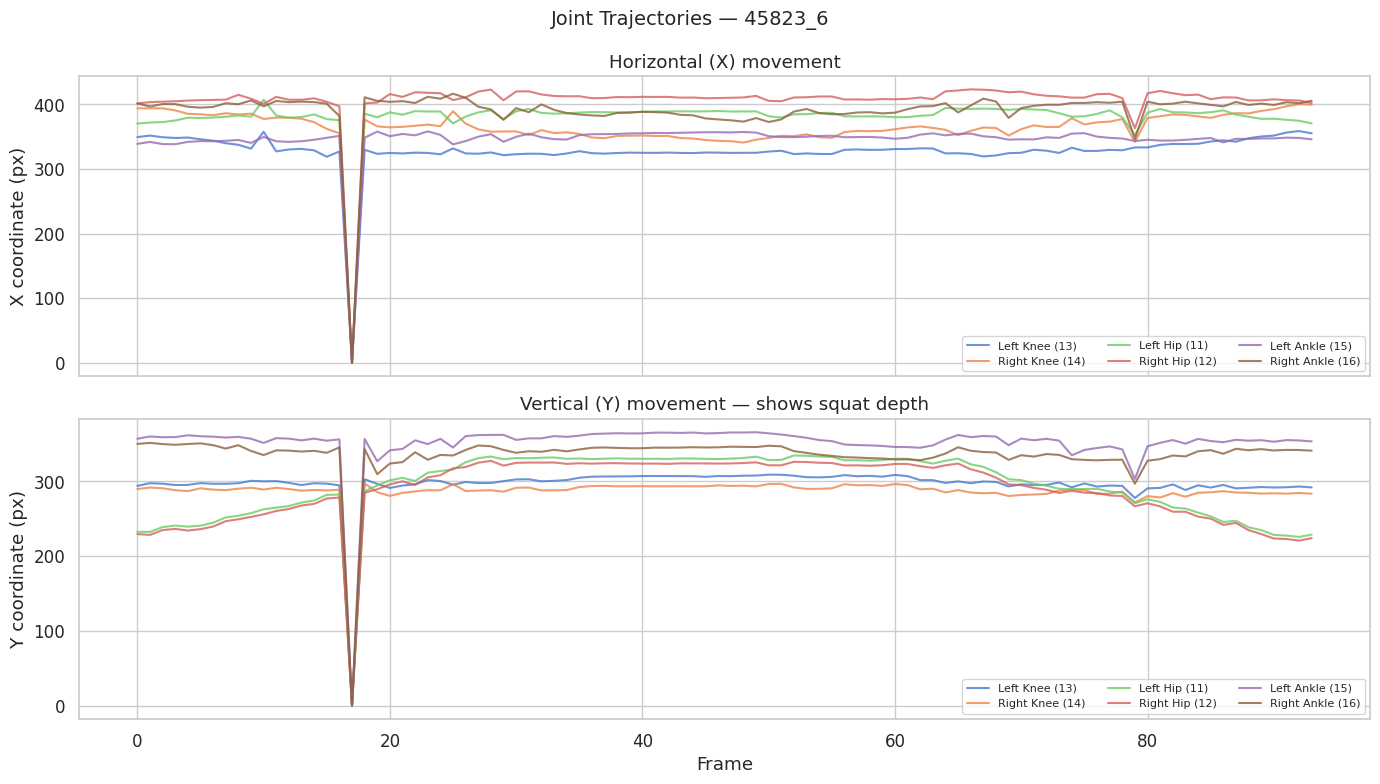

Saved → joint_trajectories.png


In [28]:
if npz_files:
    data = np.load(str(npz_files[0]))
    kps = data['keypoints']  # (T, 17, 2)
    
    key_joints = {
        'Left Knee (13)': 13,
        'Right Knee (14)': 14,
        'Left Hip (11)': 11,
        'Right Hip (12)': 12,
        'Left Ankle (15)': 15,
        'Right Ankle (16)': 16,
    }
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Joint Trajectories — {npz_files[0].stem}', fontsize=14)
    
    for name, idx in key_joints.items():
        axes[0].plot(kps[:, idx, 0], label=name, alpha=0.8)
        axes[1].plot(kps[:, idx, 1], label=name, alpha=0.8)
    
    axes[0].set_ylabel('X coordinate (px)')
    axes[0].legend(fontsize=8, ncol=3)
    axes[0].set_title('Horizontal (X) movement')
    
    axes[1].set_ylabel('Y coordinate (px)')
    axes[1].set_xlabel('Frame')
    axes[1].legend(fontsize=8, ncol=3)
    axes[1].set_title('Vertical (Y) movement — shows squat depth')
    
    plt.tight_layout()
    plt.savefig('joint_trajectories.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → joint_trajectories.png')

## 2.12  Save Dataset Metadata for Downstream Tasks

In [29]:
df.to_csv('dataset_metadata.csv', index=False)
print(f'Saved dataset_metadata.csv ({len(df)} rows)')

bench_df.to_csv('pose_model_benchmark.csv', index=False)
print(f'Saved pose_model_benchmark.csv')

config = {
    'dataset': {
        'name': 'Fitness-AQA',
        'paper': 'Domain Knowledge-Informed Self-Supervised Representations for Workout Form Assessment (ECCV 2022)',
        'arxiv': 'https://arxiv.org/abs/2202.14019',
        'exercise_type': 'squat',
        'total_trajectories': len(df),
        'splits': {'train': len(train_keys), 'val': len(val_keys), 'test': len(test_keys)},
        'error_types': ['knees_forward', 'knees_inward'],
        'nan_trajectories': len(traj_nan),
    },
    'pose_estimation': {
        'selected_model': best_model_name,
        'keypoint_format': 'COCO-17',
        'output_dir': 'keypoints/',
        'output_format': '.npz (keypoints, confidence, fps, frame_indices)',
    },
    'coco_keypoints': COCO_KEYPOINTS,
}

with open('project_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Saved project_config.json')

Saved dataset_metadata.csv (1623 rows)
Saved pose_model_benchmark.csv
Saved project_config.json


---
## Summary & Conclusions

### Task 1 — Dataset
- **Identified dataset:** Fitness-AQA (1,623 squat trajectories from real gym videos)
- **Labels available:** Exercise type (squat) + quality labels (knees-forward and knees-inward error intervals)
- **Derived quality score:** Continuous 0.0–1.0 score based on error-free fraction of each video
- **Splits ready:** 1,136 / 243 / 244 (train / val / test)

### Task 2 — Pose Estimation
- **Models compared:** MediaPipe BlazePose, YOLOv11-Pose, ViTPose (transformer)
- **All models produce** standardized COCO-17 keypoints (17 joints × 2 coordinates per frame)
- **Keypoints extracted** and saved as `.npz` files for downstream processing
- **Per-joint confidence** analysed to identify potentially unreliable joints

### Next Steps (Task 3+)
1. Normalize keypoints (hip-centered, scale-invariant)
2. Impute missing/low-confidence joints
3. Compute joint angles (knee, hip, elbow)
4. Train BiLSTM + CNN models for classification and quality scoring